## Game: Modifying Conway's Game of Life Model for Play

### Main differences from the experiment model

- The experiment model uses classic Conway birth (`exactly 3 neighbors`), while this game model uses `exactly T neighbors` **plus** spontaneous noise-driven activation.
- The experiment model has no spontaneous firing; this game model adds a per-step noise probability `p` for inactive cells.
- In the experiment model, threshold is fixed at `3`; here threshold `T` is adjustable (slider behavior).
- Defects are represented differently: experiment code often uses a separate defect mask, while the game model uses a third grid state (`-1`) for permanent defects.
- The experiment runs are typically on larger grids (e.g., `300×300`), while this game model is tuned for `60×60` gameplay.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

class GameModel:
    """
    Game version of GoL:
    - birth if exactly T neighbors OR random noise
    - defects are permanent cells with value -1
    - open boundary conditions
    """

    DEFECT = np.int8(-1) # constant value to represent defects in the grid

    def __init__(self, grid_size=60, threshold=3, noise_p=0.0, defect_frac=0.0):
        self.grid_size = grid_size
        self.threshold = int(threshold) # number of neighbors needed for birth
        self.noise_p = float(noise_p) # probability of random birth noise
        self.defect_frac = float(defect_frac) # fraction of cells that are defects
        self.grid = np.zeros((grid_size, grid_size), dtype=np.int8) # initialize grid with all cells inactive (0)
        self.defect_mask = np.zeros((grid_size, grid_size), dtype=bool) # boolean mask to track defect locations

    def initialize(self, init_density=0.20):
        self.grid = np.zeros((self.grid_size, self.grid_size), dtype=np.int8)
        self.defect_mask = np.random.random(self.grid.shape) < self.defect_frac # randomly assign defects based on defect fraction
        self.grid[self.defect_mask] = self.DEFECT # set defect cells to the DEFECT value

        inactive_mask = self.grid == 0 # only consider non-defect cells for random activation
        rand_active = np.random.random(self.grid.shape) < init_density # random activation based on initial density
        self.grid[inactive_mask & rand_active] = 1 # activate cells that are not defects based on random density

    def step(self):
        active = (self.grid == 1).astype(np.int8) # consider only active cells
        padded = np.pad(active, 1, mode='constant', constant_values=0) # pad for open boundary conditions
        nc = (padded[:-2, :-2] + padded[:-2, 1:-1] + padded[:-2, 2:] +
              padded[1:-1, :-2] + padded[1:-1, 2:] +
              padded[2:,  :-2] + padded[2:,  1:-1] + padded[2:,  2:])

        is_active = self.grid == 1 # current active cells
        is_inactive = self.grid == 0 # current inactive cells 

        survive = is_active & ((nc == 2) | (nc == 3)) # active cells survive with 2 or 3 neighbors
        born_by_rule = is_inactive & (nc == self.threshold) # inactive cells become active if they have exactly T neighbors
        born_by_noise = is_inactive & (np.random.random(self.grid.shape) < self.noise_p) # inactive cells can also become active due to random noise

        new_grid = (survive | born_by_rule | born_by_noise).astype(np.int8) # combine survival, birth by rule, and birth by noise into new grid
        new_grid[self.defect_mask] = self.DEFECT # ensure defects remain unchanged 
        self.grid = new_grid # update the grid to the new state

    def density(self):
        # Count active over all cells 
        return float(np.mean(self.grid == 1))

    def run(self, steps=250):
        values = [] # record density at each step
        for _ in range(steps):
            self.step()
            values.append(self.density())
        return np.array(values) 


def equilibrium_density(noise_p, threshold, defect_frac=0.0, grid_size=60, n_sims=8, steps=260, warmup=140, init_density=0.20):
    """ Run multiple simulations and return the average equilibrium density after warmup period."""
    vals = []
    for _ in range(n_sims):
        m = GameModel(grid_size=grid_size, threshold=threshold, noise_p=noise_p, defect_frac=defect_frac)
        m.initialize(init_density=init_density)
        series = m.run(steps=steps)
        vals.append(np.mean(series[warmup:]))
    return float(np.mean(vals))

### Step 1: GoL baseline

From the paper replication we know that classic GoL with 20% random initial density
settles to a low equilibrium density around 3–5% on the 300×300 grid.

However, the game uses a smaller 60×60 grid, and boundary effects push the equilibrium higher. So we measure the baseline density at the game's actual grid size, since every later comparison is measured relative to it.

In [20]:
# GoL baseline density (no noise, no defects, T=3)
baseline = equilibrium_density(noise_p=0.0, threshold=3, defect_frac=0.0, grid_size=60, n_sims=12, steps=300, warmup=150)
print(f'GoL baseline equilibrium density (T=3, p=0, no defects, 60x60): {baseline*100:.2f}%')
print(f'Higher than the ~3-5% seen on 300x300 grids — expected due to boundary effects on a smaller grid.')

GoL baseline equilibrium density (T=3, p=0, no defects, 60x60): 6.25%
Higher than the ~3-5% seen on 300x300 grids — expected due to boundary effects on a smaller grid.


### Step 2: Sweep noise 

The game adds the noise parameter `p` or the probability that any inactive cell spontaneously fires each step.

Sweep `p` from 0 to 10% with T=3 and no defects.  The goal is to map the density-vs-noise relationship.

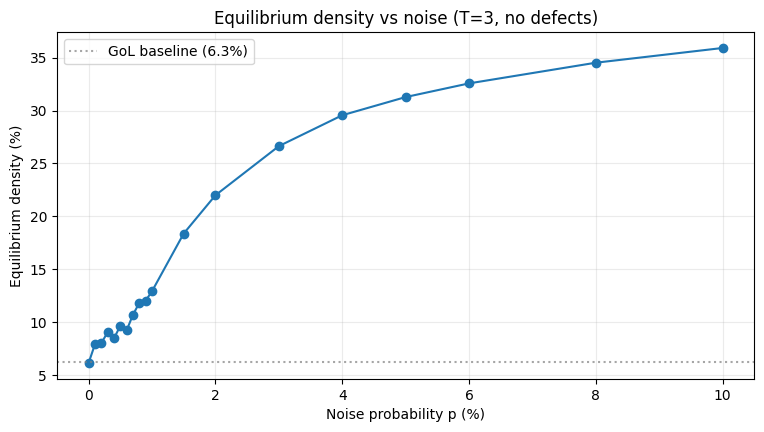

Noise sweep results (T=3):
  p=0.000 (0.0%): density= 6.13%  (1.0x baseline)
  p=0.001 (0.1%): density= 7.90%  (1.3x baseline)
  p=0.002 (0.2%): density= 8.00%  (1.3x baseline)
  p=0.003 (0.3%): density= 9.04%  (1.4x baseline)
  p=0.004 (0.4%): density= 8.46%  (1.4x baseline)
  p=0.005 (0.5%): density= 9.64%  (1.5x baseline)
  p=0.006 (0.6%): density= 9.22%  (1.5x baseline)
  p=0.007 (0.7%): density=10.70%  (1.7x baseline)
  p=0.008 (0.8%): density=11.81%  (1.9x baseline)
  p=0.009 (0.9%): density=12.03%  (1.9x baseline)
  p=0.010 (1.0%): density=12.92%  (2.1x baseline)
  p=0.015 (1.5%): density=18.38%  (2.9x baseline)
  p=0.020 (2.0%): density=21.99%  (3.5x baseline)
  p=0.030 (3.0%): density=26.64%  (4.3x baseline)
  p=0.040 (4.0%): density=29.56%  (4.7x baseline)
  p=0.050 (5.0%): density=31.28%  (5.0x baseline)
  p=0.060 (6.0%): density=32.57%  (5.2x baseline)
  p=0.080 (8.0%): density=34.53%  (5.5x baseline)
  p=0.100 (10.0%): density=35.92%  (5.7x baseline)


In [21]:
noise_values = np.array([0.000, 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, 0.010, 0.015, 0.020, 0.030, 0.040, 0.050, 0.060, 0.080, 0.100])
noise_eq = []

for p in noise_values:
    noise_eq.append(equilibrium_density(noise_p=float(p), threshold=3, defect_frac=0.0, grid_size=60, n_sims=8, steps=260, warmup=140))
noise_eq = np.array(noise_eq)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(noise_values * 100, noise_eq * 100, marker='o')
ax.axhline(baseline * 100, color='gray', linestyle=':', alpha=0.7, label=f'GoL baseline ({baseline*100:.1f}%)')
ax.set_xlabel('Noise probability p (%)')
ax.set_ylabel('Equilibrium density (%)')
ax.set_title('Equilibrium density vs noise (T=3, no defects)')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

print('Noise sweep results (T=3):')
for p, d in zip(noise_values, noise_eq):
    fold = d / baseline if baseline > 0 else float('nan')
    print(f'  p={p:.3f} ({p*100:.1f}%): density={d*100:5.2f}%  ({fold:.1f}x baseline)')

### Step 3: Noise–density relationship

From the sweep above, density rises smoothly. The curve is concave, it's steepest at very low noise, gradually flattening.

By p = 3%, density is already around ~25%, roughly 4× the baseline. Beyond this point the curve is clearly flattening, meaning additional noise produces smaller and smaller changes in density.

This is the interesting, controllable region, where small changes in noise produce meaningful changes in density and GoL structure still contributes (not in a regime where the GoL dynamic are being overriden)

So, for the game noise slider:
- slider value 0 → p = 0 
- slider value 100 → p = 0.03 

### Step 4: Threshold × noise sweep

Now that the noise range is set to [0, 0.03], we need to determine which birth threshold T produces the most interesting and controllable dynamics within that range.

Do a sweep: for each threshold T ∈ {1, 2, 3, 4, 5, 6}, measure equilibrium density
across the full noise slider range [0, 0.03]. 

Expected finding: T=3 should be the only threshold that spans a wide, controllable density range, since T=1 and T=2 saturate the grid (too many birth opportunities) and T=4–6 produce near-zero density. 

Threshold sweep:   0%|          | 0/6 [00:00<?, ?it/s]

Threshold sweep: 100%|██████████| 6/6 [00:04<00:00,  1.25it/s]


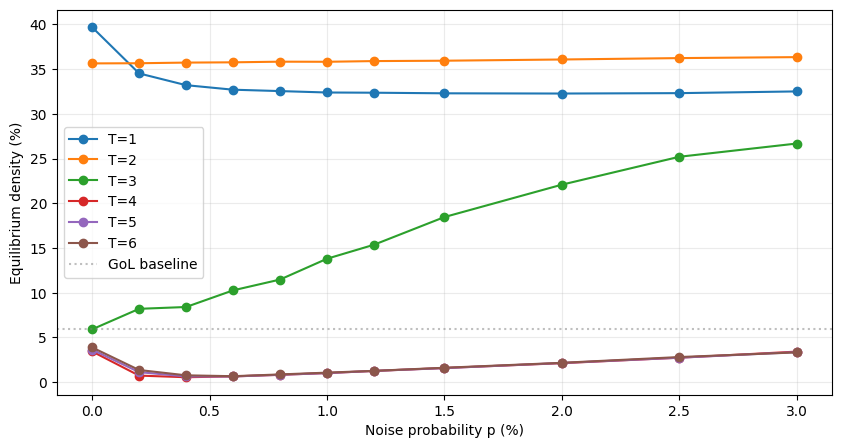

       p  T=1  T=2  T=3  T=4  T=5  T=6
    0.0%   39.7   35.6    5.9    3.4    3.6    3.9
    0.2%   34.5   35.6    8.2    0.7    1.1    1.4
    0.4%   33.2   35.7    8.4    0.6    0.6    0.8
    0.6%   32.7   35.8   10.3    0.7    0.6    0.7
    0.8%   32.5   35.8   11.5    0.8    0.8    0.9
    1.0%   32.4   35.8   13.8    1.0    1.0    1.1
    1.2%   32.4   35.9   15.4    1.3    1.3    1.3
    1.5%   32.3   35.9   18.5    1.6    1.6    1.6
    2.0%   32.3   36.1   22.1    2.1    2.1    2.2
    2.5%   32.3   36.2   25.2    2.7    2.7    2.8
    3.0%   32.5   36.3   26.7    3.4    3.4    3.3


In [6]:
# sweep threshold × noise → equilibrium density (within slider range)
threshold_scan = [1, 2, 3, 4, 5, 6]
noise_grid = np.array([0.000, 0.002, 0.004, 0.006, 0.008, 0.010, 0.012, 0.015, 0.020, 0.025, 0.030])

density_map = {}
for T in tqdm(threshold_scan, desc='Threshold sweep'):
    for p in noise_grid:
        d = equilibrium_density(noise_p=float(p), threshold=T, defect_frac=0.0, grid_size=60, n_sims=8, steps=260, warmup=140, init_density=0.20)
        density_map[(T, float(p))] = d

fig, ax = plt.subplots(figsize=(10, 5))
for T in threshold_scan:
    densities = [density_map[(T, float(p))] * 100 for p in noise_grid]
    ax.plot(noise_grid * 100, densities, marker='o', label=f'T={T}')
ax.axhline(baseline * 100, color='gray', linestyle=':', alpha=0.5, label='GoL baseline')
ax.set_xlabel('Noise probability p (%)')
ax.set_ylabel('Equilibrium density (%)')
ax.legend()
ax.grid(alpha=0.25)
plt.show()

# density table
print(f'{"p":>8s}', end='')
for T in threshold_scan:
    print(f'  T={T:d}', end='')
print()
for p in noise_grid:
    print(f'{p*100:7.1f}%', end='')
    for T in threshold_scan:
        print(f'  {density_map[(T, float(p))]*100:5.1f}', end='')
    print()

### Step 5: Defect sweep

The game has a third player-controlled parameter: defect fraction or the percentage of cells that are permanently dead.

From the paper replication, we know defects suppress activity. But we need to quantify that effect at the game grid size and within the game parameter range.

Thus, sweep defect fractions from 0% to 15% at moderate noise (p = 0.0075, slider = 25) with T=3, and observe how density responds.

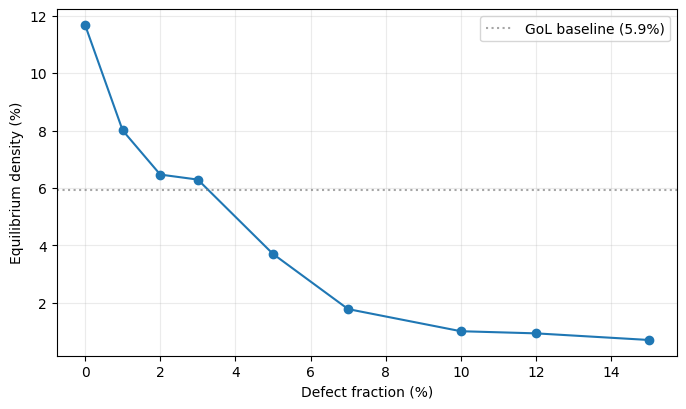

Defect sweep results (T=3, p=0.0075):
  defects=  0.0% -> density=11.68%
  defects=  1.0% -> density= 8.00%
  defects=  2.0% -> density= 6.47%
  defects=  3.0% -> density= 6.29%
  defects=  5.0% -> density= 3.70%
  defects=  7.0% -> density= 1.77%
  defects= 10.0% -> density= 1.00%
  defects= 12.0% -> density= 0.93%
  defects= 15.0% -> density= 0.70%


In [11]:
# defect sweep at T=3, moderate noise (slider=25 -> p=0.0075)
test_noise = 0.0075
defect_fracs = np.array([0.00, 0.01, 0.02, 0.03, 0.05, 0.07, 0.10, 0.12, 0.15])
defect_eq = []

for df in defect_fracs:
    d = equilibrium_density(noise_p=test_noise, threshold=3, defect_frac=float(df), grid_size=60, n_sims=8, steps=260, warmup=140 )
    defect_eq.append(d)
defect_eq = np.array(defect_eq)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(defect_fracs * 100, defect_eq * 100, marker='o')
ax.axhline(baseline * 100, color='gray', linestyle=':', alpha=0.7, label=f'GoL baseline ({baseline*100:.1f}%)')
ax.set_xlabel('Defect fraction (%)')
ax.set_ylabel('Equilibrium density (%)')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

print(f'Defect sweep results (T=3, p={test_noise}):')
for df, d in zip(defect_fracs, defect_eq):
    print(f'  defects={df*100:5.1f}% -> density={d*100:5.2f}%')

### Defect slider cap

From the sweep above:

- At around 10% defects, density has dropped substantially. The system is struggling but still alive.
- Beyond 10%, the decline accelerates toward total collapse.

Thus, cap the defect slider at 10% to keep the player in recoverable territory. This is wide enough to create real danger (density well below baseline) without making
instant collapse unavoidable.

In [12]:
MAX_DEFECT = 0.10
print(f'Defect slider cap: MAX_DEFECT = {MAX_DEFECT} ({MAX_DEFECT*100:.0f}%)')
print(f'Slider mapping: 0-100 -> 0-{MAX_DEFECT*100:.0f}% defects')

Defect slider cap: MAX_DEFECT = 0.1 (10%)
Slider mapping: 0-100 -> 0-10% defects


### Step 6: Define stable region thresholds

Complete picture of the density landscape:

- **T=3 operating range**: density spans roughly 6% to ~27% (max noise) across the slider range.
- **Defect suppression**: defects can push T=3 density well below the GoL baseline.
- **T=1, T=2**: sit at ~30-40% regardless of noise 
- **T=4-6**: sit below ~5% regardless of noise 

The game needs density bands for its health mechanic or a "stable" zone the player aims for, and "danger" zones that drain health. 

These are design choices informed by the data above, not physical transitions in the model.

**TARGET_LOW = 4%**: Below the T=3 baseline (~6-7%). At this density, GoL structures are too sparse to sustain themselves. The only way to reach this with T=3 is with defects or by switching to T>=4.

**TARGET_HIGH = 18%**: Upper portion of T=3's operating range. The grid is getting crowded but GoL patterns are still recognizable. Above this, the player is pushing toward the saturated dynamics.

**DANGER_LOW = 2.5%**: Near-total collapse. Very little is alive and recovery requires significant parameter changes.

**DANGER_HIGH = 28%**: Approaching the density levels of T=1/T=2 (~30-40%). The grid is overwhelmed with activity, seizure-like behavior.

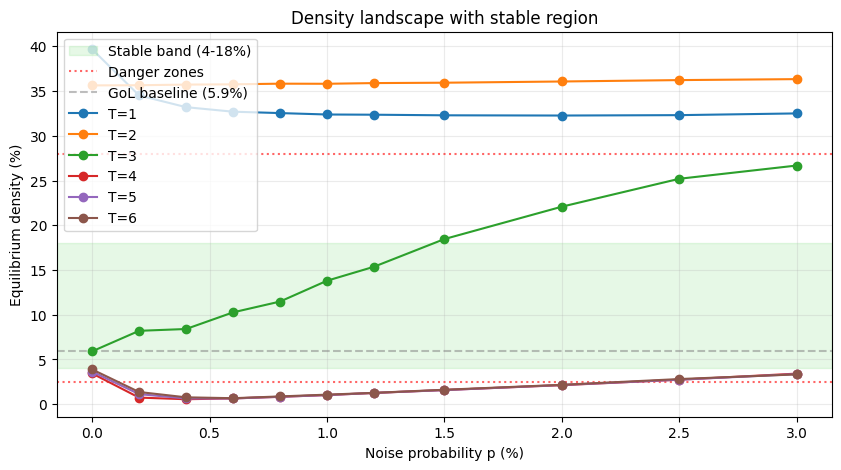

In [18]:
TARGET_LOW  = 0.04
TARGET_HIGH = 0.18
DANGER_LOW  = 0.025
DANGER_HIGH = 0.28

# landscape plot with bands overlaid
fig, ax = plt.subplots(figsize=(10, 5))
ax.axhspan(TARGET_LOW * 100, TARGET_HIGH * 100, color='limegreen', alpha=0.12, label=f'Stable band ({TARGET_LOW*100:.0f}-{TARGET_HIGH*100:.0f}%)')
ax.axhline(DANGER_LOW  * 100, color='red', linestyle=':', alpha=0.6, label='Danger zones')
ax.axhline(DANGER_HIGH * 100, color='red', linestyle=':', alpha=0.6)
ax.axhline(baseline * 100, color='gray', linestyle='--', alpha=0.5, label=f'GoL baseline ({baseline*100:.1f}%)')
for T in threshold_scan:
    densities = [density_map[(T, float(p))] * 100 for p in noise_grid]
    ax.plot(noise_grid * 100, densities, marker='o', label=f'T={T}')
ax.set_xlabel('Noise probability p (%)')
ax.set_ylabel('Equilibrium density (%)')
ax.set_title('Density landscape with stable region')
ax.legend(loc='upper left')
ax.grid(alpha=0.25)
plt.show()